# Распознавание аномалий данных с помощью автокодировщика

Практическая работа № 3 по дисциплине «Методы машинного обучения».
Московский Политех, группа 231-329, Арутюнян Ф. Р.

**Задание** взято из методических указаний к работе и материалов архива: получить практические
навыки создания, обучения и применения автокодировщиков, исследовать влияние архитектуры
и числа эпох на область, которую автокодировщик распознаёт, и решить задачу обнаружения аномалий,
используя автокодировщик как одноклассовый классификатор.

**Как устроено обнаружение.** Автокодировщик учится восстанавливать на выходе свой вход, проходя
через узкое горлышко скрытых слоёв. На данных, похожих на обучающие, ошибка восстановления (IRE)
маленькая, на непохожих большая. Порог IREth это максимальная ошибка на обучающей выборке:
всё, что восстанавливается хуже порога, считается аномалией.

**Библиотека.** Использую `lab02_lib.py` из материалов к работе. Она написана под старые версии
scikit-learn и TensorFlow, поэтому я перенёс её на актуальные: изменения перечислены в начале файла,
логика функций не менялась. Главное изменение: архитектура передаётся параметром, а не вводится
с клавиатуры, чтобы ноутбук выполнялся целиком без ручного ввода.

**План:**
1. Синтетический двумерный набор, как в методичке.
2. Автокодировщики AE1 (простой) и AE2 (глубокий): обучение и ошибка реконструкции.
3. Характеристики качества EDCA и области, которые распознаёт каждый автокодировщик.
4. Тестовая выборка с аномалиями.
5. Реальные данные из архива: WBC, cardio, letter.

## 0. Библиотеки и настройки

In [1]:
import os
import re
import shutil

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # убираем служебный вывод TensorFlow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split

import lab02_lib as lib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 80

RANDOM_STATE = 42
tf.keras.utils.set_random_seed(RANDOM_STATE)   # фиксирует numpy, python и TensorFlow

os.makedirs('out', exist_ok=True)       # сюда пишет библиотека
os.makedirs('figures', exist_ok=True)   # сюда копирую графики для отчёта
print('TensorFlow', tf.__version__)


def keep(src, dst):
    """Копирует график, сохранённый библиотекой, в figures/ под номером для отчёта."""
    shutil.copy(os.path.join('out', src), os.path.join('figures', dst))


def read_edca():
    """Характеристики EDCA из файла, который пишет lib.square_calc."""
    text = open('out/result.txt', encoding='utf-8').read()
    return {k: float(v) for k, v in re.findall(r'(Approx|Excess|Deficit|Coating) = ([\d.eE+-]+)', text)}

TensorFlow 2.21.0


## 1. Синтетический набор данных

По методичке генерирую двумерный набор из 1000 точек с центром в точке (5, 5).
Функция `lib.datagen` строит облако точек с разбросом 0,1, рисует его и сохраняет в `data.txt`.

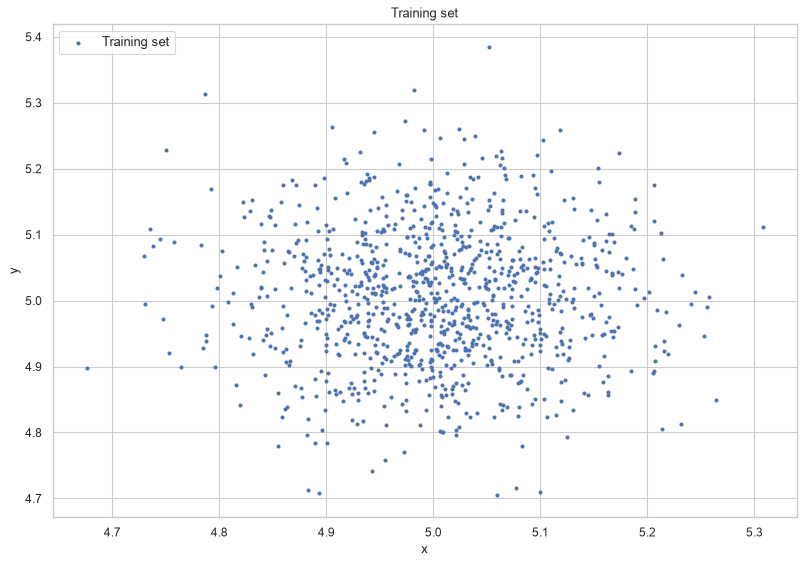

Размерность данных: (1000, 2)
Центр облака: [5.003 5.006] | разброс: [0.096 0.101]


In [2]:
data = lib.datagen(5, 5, 1000, 2, random_state=RANDOM_STATE)
keep('train_set.png', '01_train_set.png')
print('Размерность данных:', data.shape)
print('Центр облака:', data.mean(axis=0).round(3), '| разброс:', data.std(axis=0).round(3))

**Рисунок 1 — Синтетическая обучающая выборка**

Облако из 1000 точек с центром (5,003; 5,006) и разбросом около 0,1 по обеим осям, то есть обучающие данные занимают маленький круг.

## 2. Обучение автокодировщиков

**AE1** с минимальной архитектурой: один скрытый слой из одного нейрона. Всё двумерное облако
должно пройти через одно число, поэтому восстановление грубое. Методичка требует, чтобы MSE_stop
у первого автокодировщика оставалась заметной, это и есть намеренно слабая модель.

**AE2** с архитектурой по умолчанию из библиотеки: скрытые слои 3, 2, 1, 2, 3. Глубже, поэтому
точнее аппроксимирует облако. Обучение 3000 эпох.

Параметр patience = 300: если ошибка 300 эпох подряд не уменьшается, обучение останавливается.

In [3]:
patience = 300
ae1, IRE1, IREth1 = lib.create_fit_save_ae(data, 'out/AE1.h5', 'out/AE1_ire_th.txt',
                                           1000, False, patience, arch=[1])
print(f'AE1: эпох {ae1.epochs_done}, MSE_stop {ae1.mse_stop:.5f}, порог IREth1 = {IREth1}')

 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step




AE1: эпох 1000, MSE_stop 7.82549, порог IREth1 = 4.29


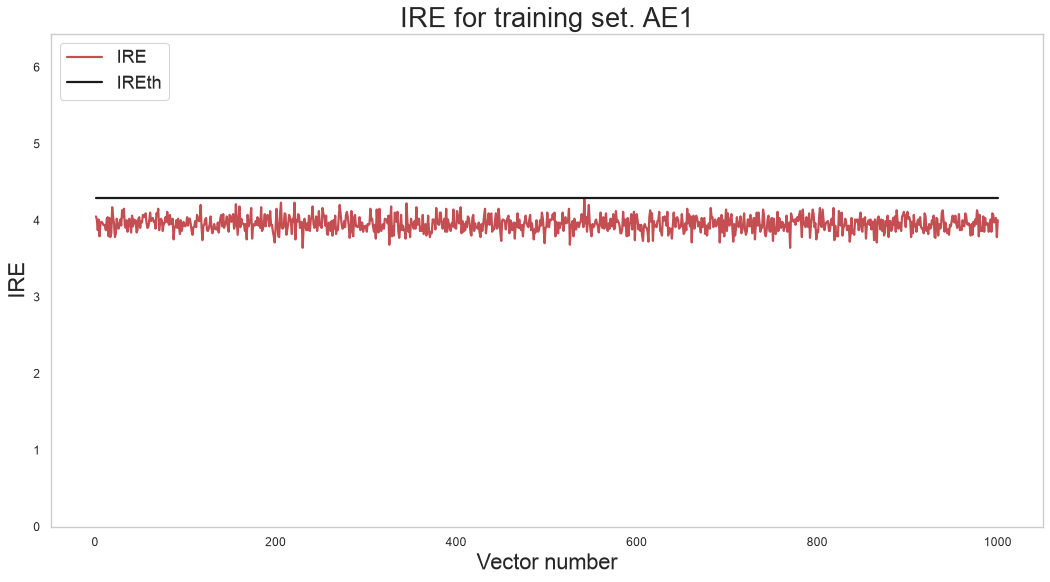

IRE на обучении: медиана 3.950, максимум 4.290


In [4]:
lib.ire_plot('training', IRE1, IREth1, 'AE1')
keep('IRE_trainingAE1.png', '02_ire_train_ae1.png')
print(f'IRE на обучении: медиана {np.median(IRE1):.3f}, максимум {IRE1.max():.3f}')

**Рисунок 2 — Ошибка реконструкции обучающей выборки для AE1**

У AE1 ошибка реконструкции большая у всех точек (порог IREth1 = 4,29), MSE_stop 7,83: одного нейрона в горлышке мало, чтобы восстановить двумерную точку.

Epoch 2701: early stopping


 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 




AE2: эпох 2701, MSE_stop 0.00977, порог IREth2 = 0.38


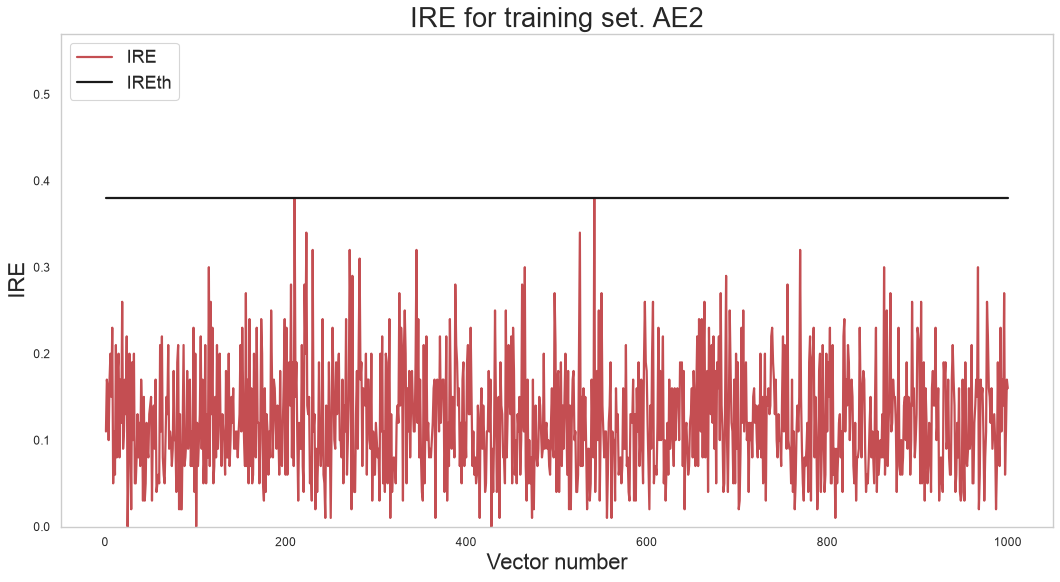

IRE на обучении: медиана 0.110, максимум 0.380


In [5]:
ae2, IRE2, IREth2 = lib.create_fit_save_ae(data, 'out/AE2.h5', 'out/AE2_ire_th.txt',
                                           3000, False, patience)
print(f'AE2: эпох {ae2.epochs_done}, MSE_stop {ae2.mse_stop:.5f}, порог IREth2 = {IREth2}')
lib.ire_plot('training', IRE2, IREth2, 'AE2')
keep('IRE_trainingAE2.png', '03_ire_train_ae2.png')
print(f'IRE на обучении: медиана {np.median(IRE2):.3f}, максимум {IRE2.max():.3f}')

**Рисунок 3 — Ошибка реконструкции обучающей выборки для AE2**

У AE2 ошибка на порядок меньше (порог IREth2 = 0,38, MSE_stop 0,0098), обучение остановилось на 2701-й эпохе по правилу patience.

## 3. Характеристики качества EDCA

Функция `lib.square_calc` делит пространство признаков сеткой 20 на 20 и сравнивает две области:
клетки, где лежат обучающие точки (|Xt|), и клетки, которые автокодировщик относит к своему классу (|Xd|).

- **Excess**: доля лишних клеток, которые автокодировщик принимает за свои, хотя обучающих точек там нет.
  Идеал 0. Большой Excess значит, что аномалии в этой области пройдут незамеченными.
- **Deficit**: доля клеток обучающей выборки, которые автокодировщик не распознал. Идеал 0.
- **Coating**: доля клеток обучающей выборки, покрытых распознанной областью. Идеал 1.
- **Approx**: отношение площадей |Xt| / |Xd|. Идеал 1, маленькое значение означает сильно раздутую область.

  1/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 211us/step


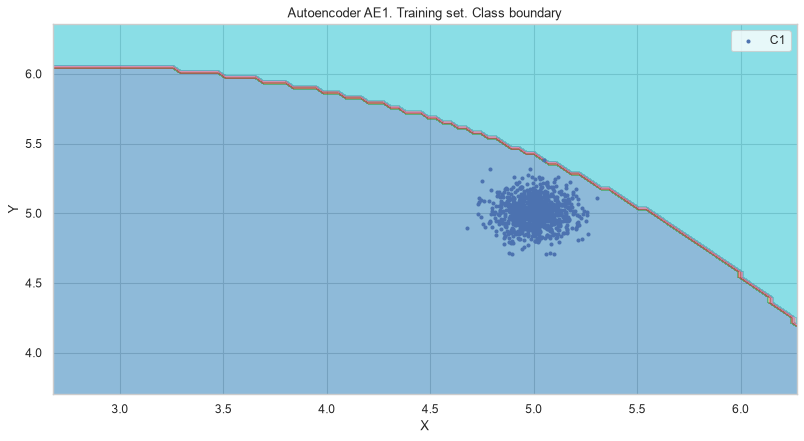

amount:  20
amount_ae:  285


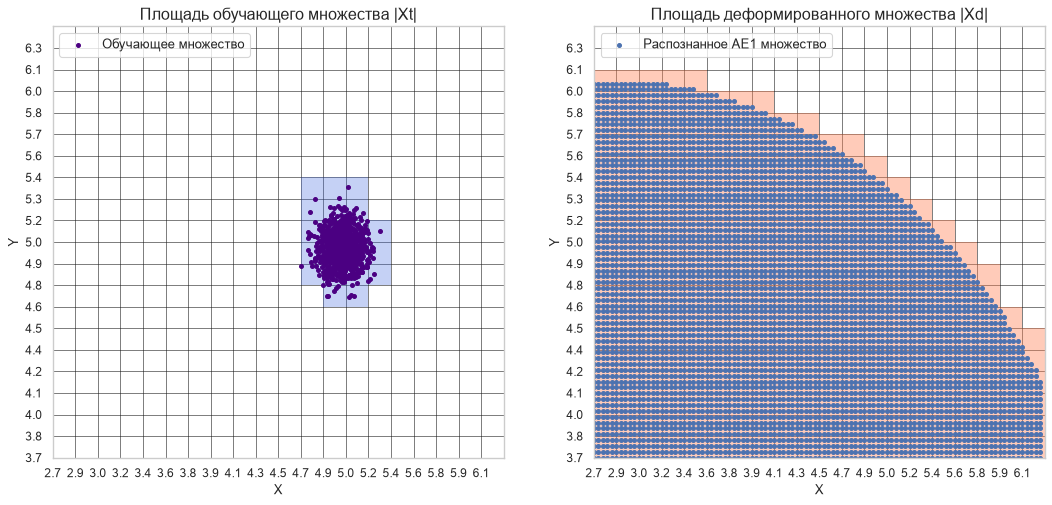

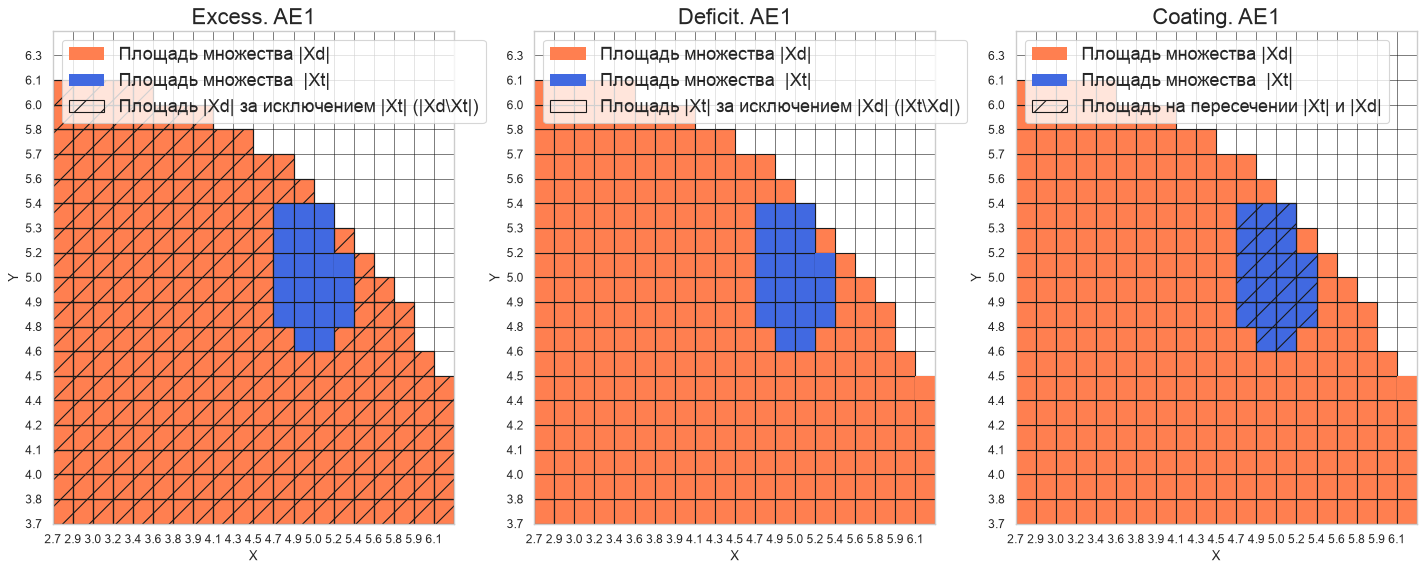


Оценка качества AE1
IDEAL = 0. Excess:  13.25
IDEAL = 0. Deficit:  0.0
IDEAL = 1. Coating:  1.0
summa:  1.0
IDEAL = 1. Extrapolation precision (Approx):  0.07017543859649122




In [6]:
numb_square = 20
xx, yy, Z1 = lib.square_calc(numb_square, data, ae1, IREth1, '1', True)
edca1 = read_edca()
keep('XtXd_1_metrics.png', '04_edca_ae1.png')

**Рисунок 4 — Области Excess, Deficit и Coating для AE1**

AE1 относит к своему классу огромную область: Excess 13,25, Approx 0,070, то есть распознанная площадь в 14 раз больше площади обучающих данных.

  1/232 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 234us/step


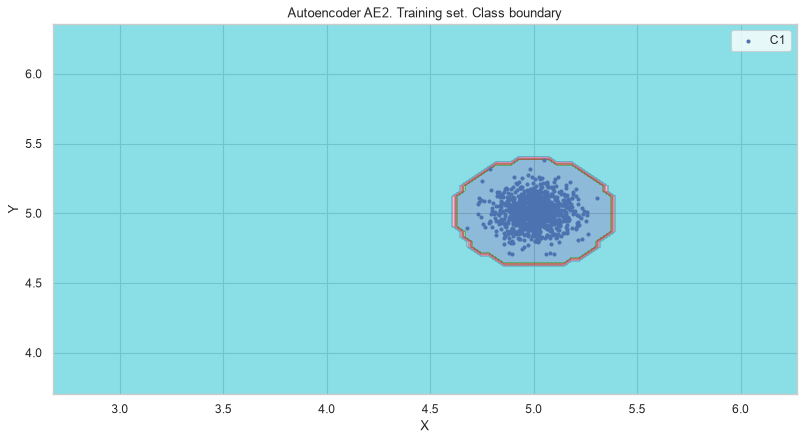

amount:  20
amount_ae:  26


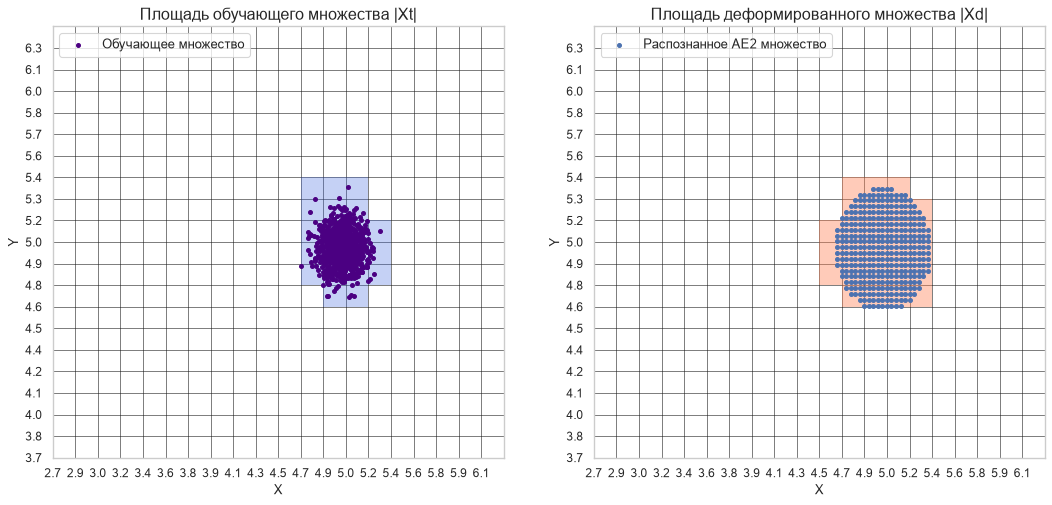

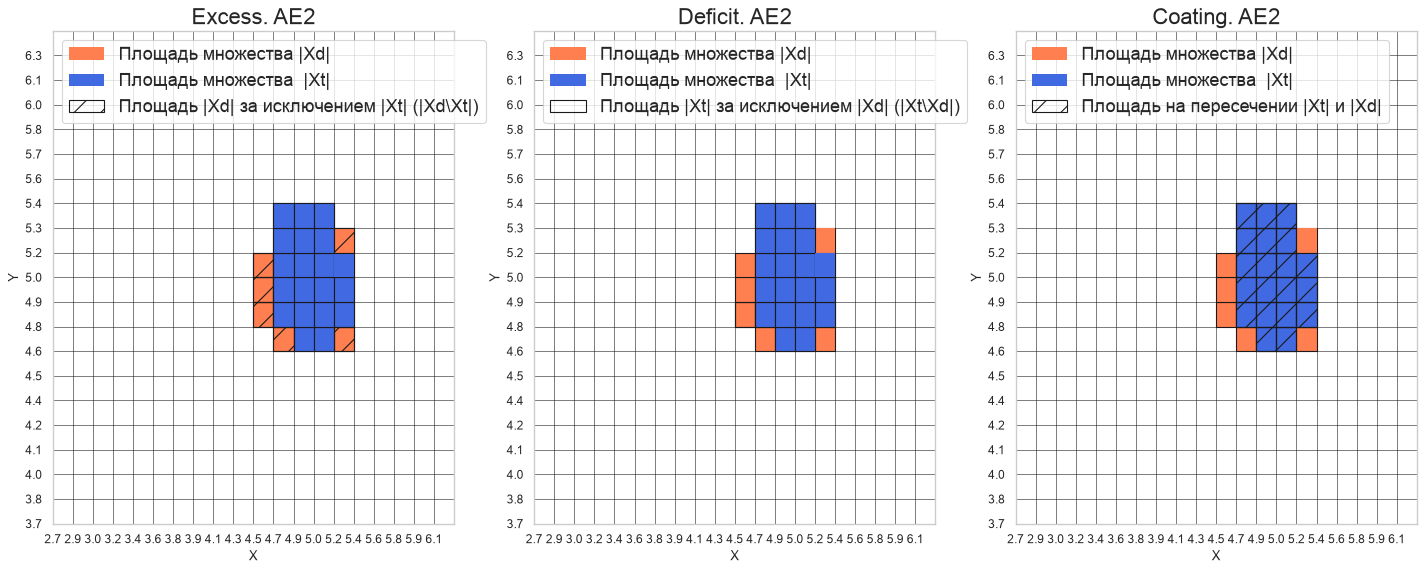


Оценка качества AE2
IDEAL = 0. Excess:  0.3
IDEAL = 0. Deficit:  0.0
IDEAL = 1. Coating:  1.0
summa:  1.0
IDEAL = 1. Extrapolation precision (Approx):  0.7692307692307693




In [7]:
xx, yy, Z2 = lib.square_calc(numb_square, data, ae2, IREth2, '2', True)
edca2 = read_edca()
keep('XtXd_2_metrics.png', '05_edca_ae2.png')

**Рисунок 5 — Области Excess, Deficit и Coating для AE2**

AE2 очерчивает облако плотно: Excess 0,30, Deficit 0, Coating 1, Approx 0,769, это близко к идеальному автокодировщику.

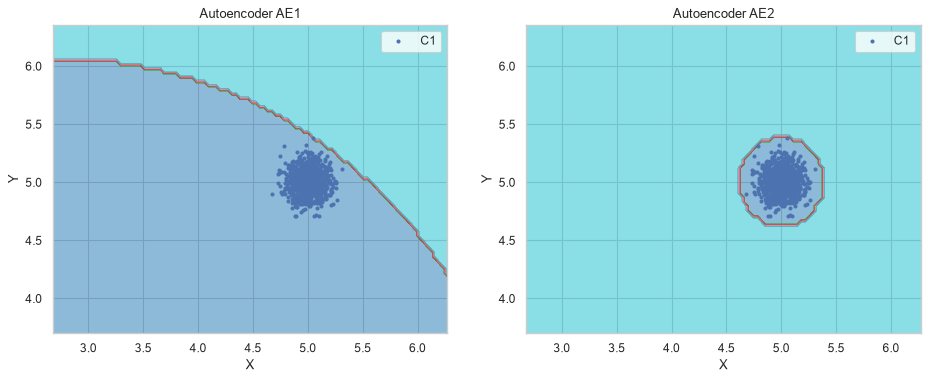

,Excess,Deficit,Coating,Approx
AE1,13.25,0.0,1.0,0.070
AE2,0.30,0.0,1.0,0.769
Идеальный AE,0.00,0.0,1.0,1.000


In [8]:
plt.figure(figsize=(14, 5))
lib.plot2in1(data, xx, yy, Z1, Z2)
keep('AE1_AE2_train_def.png', '06_areas_ae1_ae2.png')

edca = pd.DataFrame([edca1, edca2, {'Excess': 0, 'Deficit': 0, 'Coating': 1, 'Approx': 1}],
                    index=['AE1', 'AE2', 'Идеальный AE'])[['Excess', 'Deficit', 'Coating', 'Approx']]
edca.round(3)

**Рисунок 6 — Области, которые AE1 и AE2 относят к обучающему классу**

Область AE1 растянута далеко за пределы облака, область AE2 почти совпадает с ним, как и в примере из методички.

## 4. Тестирование на выборке с аномалиями

Методичка предлагает самому составить тестовую выборку. Беру 10 точек: 3 внутри облака
и 7 на разном удалении от него. Для каждой точки заранее известно, аномалия это или нет,
поэтому можно проверить, кто из автокодировщиков прав.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


===== AE1, порог 4.29

i         Labels    IRE       IREth     
0         [0.]      [3.94]    4.29      
1         [0.]      [3.93]    4.29      
2         [0.]      [3.98]    4.29      
3         [0.]      [4.25]    4.29      
4         [0.]      [3.25]    4.29      
5         [1.]      [4.45]    4.29      
6         [1.]      [5.34]    4.29      
7         [0.]      [3.47]    4.29      
8         [1.]      [4.36]    4.29      
9         [0.]      [3.32]    4.29      
Обнаружено  3.0  аномалий


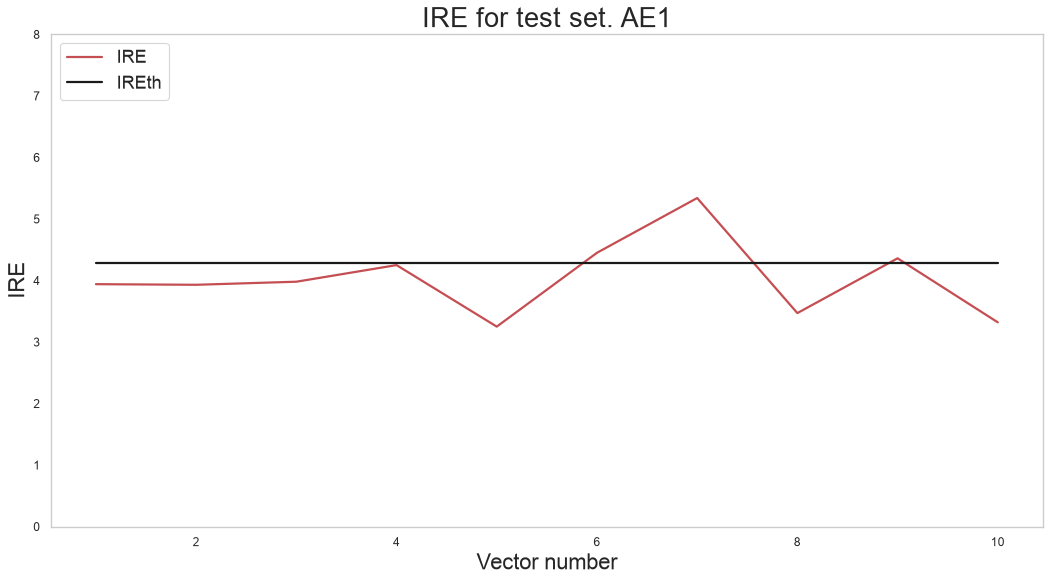


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


===== AE2, порог 0.38

i         Labels    IRE       IREth     
0         [0.]      [0.01]    0.38      
1         [0.]      [0.07]    0.38      
2         [0.]      [0.09]    0.38      
3         [1.]      [0.5]     0.38      
4         [1.]      [0.71]    0.38      
5         [1.]      [0.6]     0.38      
6         [1.]      [1.41]    0.38      
7         [1.]      [1.]      0.38      
8         [1.]      [0.42]    0.38      
9         [1.]      [0.8]     0.38      
Обнаружено  7.0  аномалий


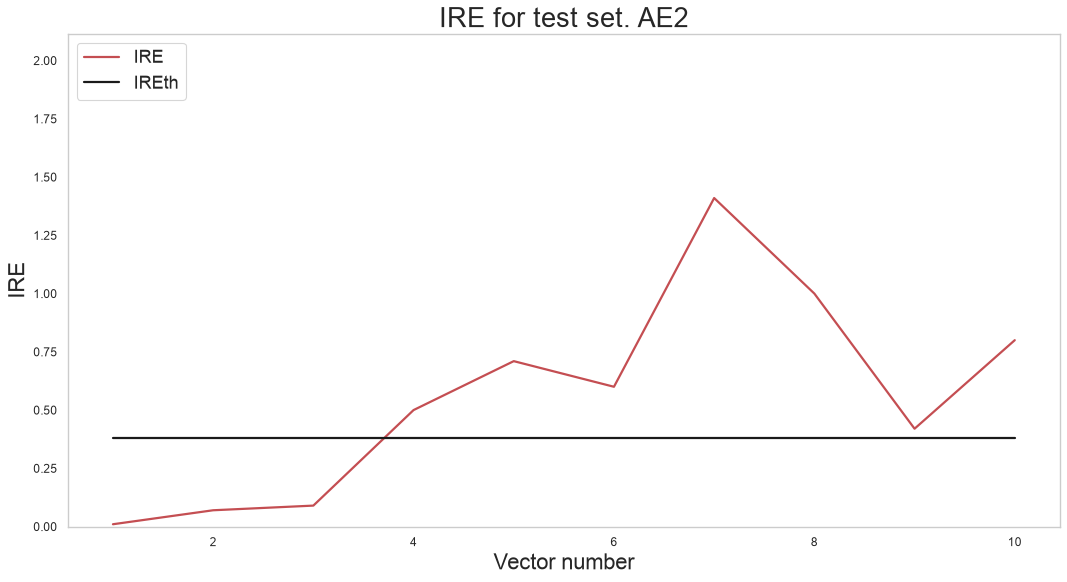

,Найдено аномалий из 7,Ложных тревог из 3,Верных ответов из 10
AE1,3,0,6
AE2,7,0,10


In [9]:
data_test = np.array([
    [5.00, 5.00], [5.05, 4.95], [4.95, 5.08],                 # внутри облака
    [5.50, 5.00], [4.50, 4.50], [5.00, 5.60], [6.00, 6.00],   # аномалии рядом
    [4.00, 5.00], [5.30, 5.30], [5.00, 4.20],                 # и подальше
])
truth = np.array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1])
np.savetxt('data_test.txt', data_test)

results_2d = {}
for name, ae, th in [('AE1', ae1, IREth1), ('AE2', ae2, IREth2)]:
    labels, ire = lib.predict_ae(ae, data_test, th)
    print(f'===== {name}, порог {th}')
    lib.anomaly_detection_ae(labels, ire, th)
    pred = labels.ravel().astype(int)
    results_2d[name] = {
        'Найдено аномалий из 7': int(((pred == 1) & (truth == 1)).sum()),
        'Ложных тревог из 3': int(((pred == 1) & (truth == 0)).sum()),
        'Верных ответов из 10': int((pred == truth).sum()),
    }
    lib.ire_plot('test', ire, th, name)
    print()

keep('IRE_testAE1.png', '07_ire_test_ae1.png')
keep('IRE_testAE2.png', '08_ire_test_ae2.png')
pd.DataFrame(results_2d).T

**Рисунок 7 — Ошибка реконструкции тестовой выборки для AE1**

AE1 нашёл только 3 аномалии из 7: у пропущенных аномалий ошибка от 3,25 до 4,25 ниже его завышенного порога 4,29, а у точек внутри облака она даже выше (3,93–3,98), то есть AE1 норму от аномалий не отличает.

**Рисунок 8 — Ошибка реконструкции тестовой выборки для AE2**

AE2 нашёл все 7 аномалий и не дал ни одной ложной тревоги: у точек внутри облака ошибка 0,01–0,09, у аномалий от 0,42 до 1,41 при пороге 0,38.

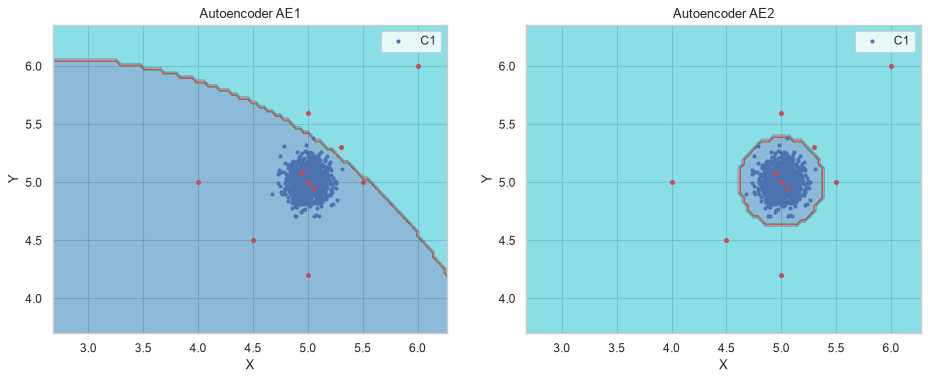

In [10]:
plt.figure(figsize=(14, 5))
lib.plot2in1_anomaly(data, xx, yy, Z1, Z2, data_test)
keep('AE1_AE2_train_def_anomalies.png', '09_test_on_areas.png')

**Рисунок 9 — Тестовые точки на фоне областей AE1 и AE2**

Красные тестовые точки внутри области AE1 он пропускает, а область AE2 настолько узкая, что все точки вне облака оказываются за её границей.

## 5. Реальные данные из архива

В архиве к работе три набора: WBC (опухоли молочной железы, 30 признаков), cardio (кардиотокография,
21 признак) и letter (распознавание букв, 32 признака). Это наборы из известного бенчмарка
обнаружения аномалий ODDS: обучающий файл содержит только нормальные объекты, тестовый только аномалии.

Чтобы оценить не только долю найденных аномалий, но и ложные тревоги, откладываю 20 % нормальных
объектов: автокодировщик их не видит, и хороший детектор не должен считать их аномалиями.

Архитектура для многомерных данных шире, чем в двумерном примере: скрытые слои сужаются примерно
вдвое на каждом шаге до горлышка из 4 нейронов.

In [11]:
real_rows = []
real_ire = {}

for name, arch in [('WBC', [16, 8, 4, 8, 16]), ('cardio', [12, 6, 4, 6, 12]), ('letter', [16, 8, 4, 8, 16])]:
    normal = np.loadtxt(f'data/{name}_train.txt')
    anomalies = np.loadtxt(f'data/{name}_test.txt')
    tr, hold = train_test_split(normal, test_size=0.2, random_state=RANDOM_STATE)

    ae, ire_tr, th = lib.create_fit_save_ae(tr, f'out/{name}.h5', f'out/{name}_ire_th.txt',
                                            3000, False, patience, arch=arch)
    lab_hold, ire_hold = lib.predict_ae(ae, hold, th)
    lab_an, ire_an = lib.predict_ae(ae, anomalies, th)

    # второй вариант порога: 99-й процентиль вместо максимума, он не зависит от одного выброса
    th99 = float(np.percentile(ire_tr, 99))
    real_ire[name] = (ire_tr, ire_hold.ravel(), ire_an.ravel(), th, th99)
    real_rows.append({
        'Набор': name,
        'Признаков': normal.shape[1],
        'Обучение': len(tr),
        'Отложено норм.': len(hold),
        'Аномалий': len(anomalies),
        'MSE_stop': round(ae.mse_stop, 5),
        'IREth': th,
        'Найдено аномалий': f'{int(lab_an.sum())} из {len(anomalies)}',
        'Доля найденных': lab_an.mean(),
        'Ложные тревоги': lab_hold.mean(),
        'Доля найденных (p99)': (ire_an.ravel() > th99).mean(),
        'Ложные тревоги (p99)': (ire_hold.ravel() > th99).mean(),
    })
    print(f'{name}: эпох {ae.epochs_done}, порог {th}, найдено {int(lab_an.sum())} из {len(anomalies)}, '
          f'ложных тревог {int(lab_hold.sum())} из {len(hold)}')

real = pd.DataFrame(real_rows).set_index('Набор')
real.round(3)

Epoch 1265: early stopping


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 




1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


letter: эпох 1469, порог 29.78, найдено 0 из 100, ложных тревог 0 из 300


,Признаков,Обучение,Отложено норм.,Аномалий,MSE_stop,IREth,Найдено аномалий,Доля найденных,Ложные тревоги,Доля найденных (p99),Ложные тревоги (p99)
Набор,,,,,,,,,,,
WBC,30,285,72,21,0.002,0.80,5 из 21,0.238,0.014,0.381,0.014
cardio,21,1323,331,176,0.208,9.02,7 из 176,0.040,0.000,0.386,0.012
letter,32,1200,300,100,5.992,29.78,0 из 100,0.000,0.000,0.010,0.010


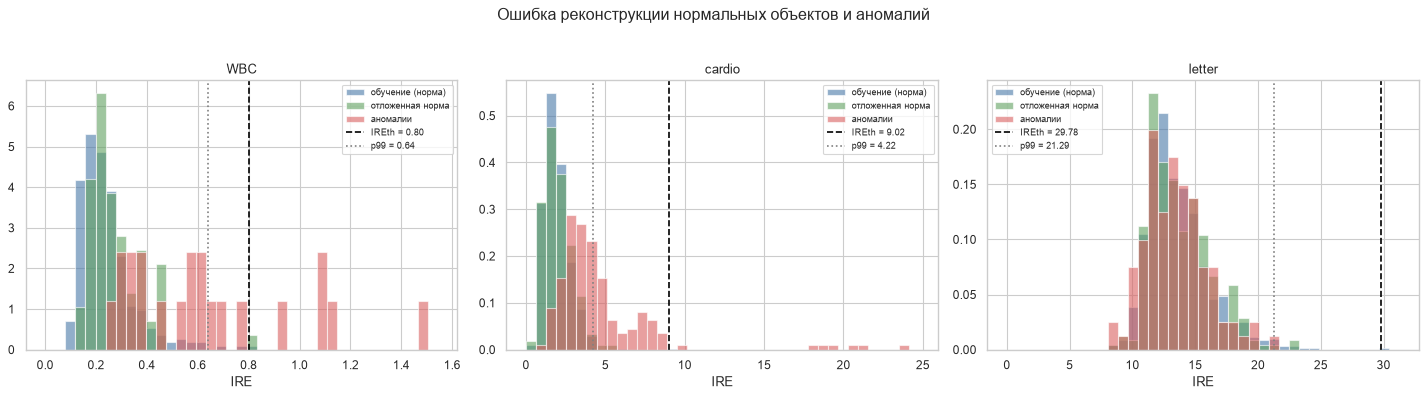

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, (name, (ire_tr, ire_hold, ire_an, th, th99)) in zip(axes, real_ire.items()):
    bins = np.linspace(0, max(ire_an.max(), ire_tr.max()) * 1.05, 40)
    ax.hist(ire_tr, bins=bins, alpha=0.6, label='обучение (норма)', color='#4878a8', density=True)
    ax.hist(ire_hold, bins=bins, alpha=0.6, label='отложенная норма', color='#5fa05f', density=True)
    ax.hist(ire_an, bins=bins, alpha=0.6, label='аномалии', color='#d95f5f', density=True)
    ax.axvline(th, color='black', linestyle='--', label=f'IREth = {th:.2f}')
    ax.axvline(th99, color='gray', linestyle=':', label=f'p99 = {th99:.2f}')
    ax.set_title(name)
    ax.set_xlabel('IRE')
    ax.legend(fontsize=8)
fig.suptitle('Ошибка реконструкции нормальных объектов и аномалий', y=1.03)
fig.tight_layout()
plt.savefig('figures/10_real_ire.png', dpi=150, bbox_inches='tight')
plt.show()

**Рисунок 10 — Распределения ошибки реконструкции на реальных данных**

У WBC и cardio ошибки аномалий в среднем выше, чем у нормы, но распределения перекрываются, а у letter аномалии восстанавливаются так же, как норма.

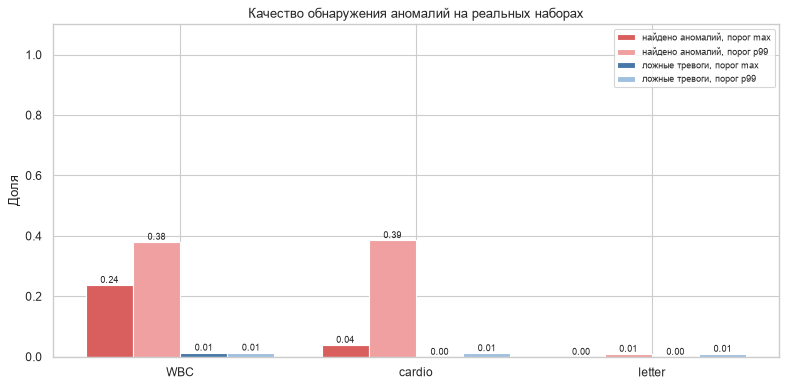

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(real))
w = 0.2
cols = [('Доля найденных', '#d95f5f', 'найдено аномалий, порог max'),
        ('Доля найденных (p99)', '#f0a0a0', 'найдено аномалий, порог p99'),
        ('Ложные тревоги', '#4878a8', 'ложные тревоги, порог max'),
        ('Ложные тревоги (p99)', '#a0c0e0', 'ложные тревоги, порог p99')]
for k, (col, color, label) in enumerate(cols):
    bars = ax.bar(x + (k - 1.5) * w, real[col], w, color=color, label=label)
    ax.bar_label(bars, fmt='%.2f', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(real.index)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Доля')
ax.set_title('Качество обнаружения аномалий на реальных наборах')
ax.legend(fontsize=8, loc='upper right')
fig.tight_layout()
plt.savefig('figures/11_real_summary.png', dpi=150, bbox_inches='tight')
plt.show()

**Рисунок 11 — Доля найденных аномалий и ложных тревог на реальных наборах**

С порогом по максимуму найдено только 23,8 % аномалий WBC и 4,0 % cardio, порог по 99-му процентилю поднимает это до 38,1 % и 38,6 % при ложных тревогах около 1 %, на letter автокодировщик не работает.

## 6. Выводы

1. **Библиотека перенесена.** `lab02_lib.py` заработала на Python 3.12, TensorFlow 2.21 и Keras 3.15
   после шести изменений: импорт make_blobs, аргумент learning_rate у Adam, конструктор callback,
   архитектура параметром вместо ручного ввода, фиксированный random_state и сохранение MSE_stop.

2. **Двумерный пример повторяет методичку.** AE1 с одним нейроном в горлышке обучился до MSE_stop 7,83,
   AE2 с архитектурой 3, 2, 1, 2, 3 до 0,0098, это соответствует требованиям методички (у первого
   не меньше единицы, у второго около 0,01).

   | Автокодировщик | Excess | Deficit | Coating | Approx |
   |---|---|---|---|---|
   | AE1 | 13,25 | 0 | 1 | 0,070 |
   | AE2 | 0,30 | 0 | 1 | 0,769 |
   | Идеальный | 0 | 0 | 1 | 1 |

   В методичке у AE1 Excess 11,25 и Approx 0,08, у AE2 0,5 и 0,67, мои числа того же порядка.

3. **Тест.** AE2 нашёл все 7 аномалий без ложных тревог, AE1 только 3 из 7. Слабая архитектура
   очерчивает слишком большую область, и аномалии внутри неё проходят незамеченными.
   Это и есть уязвимость, о которой говорит методичка.

4. **Реальные данные дают скромный результат, и это честный итог.** Порог по максимальной ошибке
   на обучении слишком строгий: один нетипичный нормальный объект задирает порог.
   С ним найдено 23,8 % аномалий WBC и 4,0 % cardio. Порог по 99-му процентилю даёт 38,1 % и 38,6 %
   при ложных тревогах около 1 %. На letter автокодировщик не работает: аномальные буквы
   по расстоянию до центра не отличаются от нормальных (медианы 13,12 и 13,16), а признаки от 0 до 15
   без нормализации дали MSE_stop 5,99, модель недообучена.

5. **Что улучшило бы результат:** нормализация признаков перед обучением, выбор порога по отложенной
   норме с заданной долей ложных тревог, более широкое горлышко для многомерных данных, сравнение
   с Isolation Forest или One-Class SVM.